# Homework 3

For this assignment, you will be developing an artificial neural network to classify data given in the __[Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality)__. This data set was obtained as a part of a research study by University of
Minho, Portugal, where the quality of multiple different wines is classified on a scale of 1-10. More details on the study can be found in the following __[research paper](https://repositorium.sdum.uminho.pt/bitstream/1822/10029/1/wine5.pdf)__.

## About the Data Set
Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. We are using the white wine data set that provided in the zip file for your. The goal is to model wine quality based on physicochemical tests (see __[Cortez et al., 2009](http://www3.dsi.uminho.pt/pcortez/wine/)__).
This datasets is related to red variants of the Portuguese "Vinho Verde" wine.The dataset describes the amount of various chemicals present in wine and their effect on it's quality. The datasets can be viewed as classification or regression tasks. The classes are ordered and not balanced (e.g. there are much more normal wines than excellent or poor ones). Your task is to predict the quality of wine using the given data. For this assignment, we are considering this as a classification problem where you will classify the data into 1-10 different levels of quality.

Number of Instances (records in the data set): __4898__

Number of Attributes (fields within each record, including the class): __12__

### Data Set Attribute Information:
__Input variables (based on physicochemical tests):__

1 - fixed acidity\
2 - volatile acidity\
3 - citric acid\
4 - residual sugar\
5 - chlorides\
6 - free sulfur dioxide\
7 - total sulfur dioxide\
8 - density\
9 - pH\
10 - sulphates\
11 - alcohol

__Output variable (based on sensory data):__

12 - quality (score between 0 and 10)

### Libraries that can be used :
- NumPy, SciPy, Pandas, Sci-Kit Learn, TensorFlow, Keras, seaborn, plotly, matplotlib
- Any other library are fine to use if you could finish the task correctly.

### Other Notes
- __Don't worry about getting a very high accuracy__
- Discussion materials should be helpful for doing the assignments.
- The homework submission should be a .pdf file.


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
%cd drive/MyDrive/ecs171/hw3/

/content/drive/MyDrive/ecs171/hw3


In [3]:
%ls

winequality-white.csv


In [4]:
import pandas as pd
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
from sklearn.model_selection import train_test_split
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import KFold
import random


# Outputs
Please output exactly what is asked.

## Exercise 1 - General Data Preprocessing (15 points)
Follow what's have done in hw2 exercise1 and preporcess the data for this homework.
- As the classes are categorical, use one-hot encoding to represent the set of classes. You will find this useful when developing the output layer of the neural network.
    - __Note__ the dataset doesn't include data points from all grading levels, but you may still need to create the one-hot encoding by 10 cols.
- Normalize each field of the input data using the min-max normalization technique.
- Output :
    - The first 5 rows of your processed data.
    - A pairplot of the input variables.

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0       0.307692          0.186275     0.216867        0.308282   0.106825   
1       0.240385          0.215686     0.204819        0.015337   0.118694   
2       0.413462          0.196078     0.240964        0.096626   0.121662   
3       0.326923          0.147059     0.192771        0.121166   0.145401   
4       0.326923          0.147059     0.192771        0.121166   0.145401   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0             0.149826              0.373550  0.267785  0.254545   0.267442   
1             0.041812              0.285383  0.132832  0.527273   0.313953   
2             0.097561              0.204176  0.154039  0.490909   0.255814   
3             0.156794              0.410673  0.163678  0.427273   0.209302   
4             0.156794              0.410673  0.163678  0.427273   0.209302   

    alcohol                          quality_vec  
0  0.

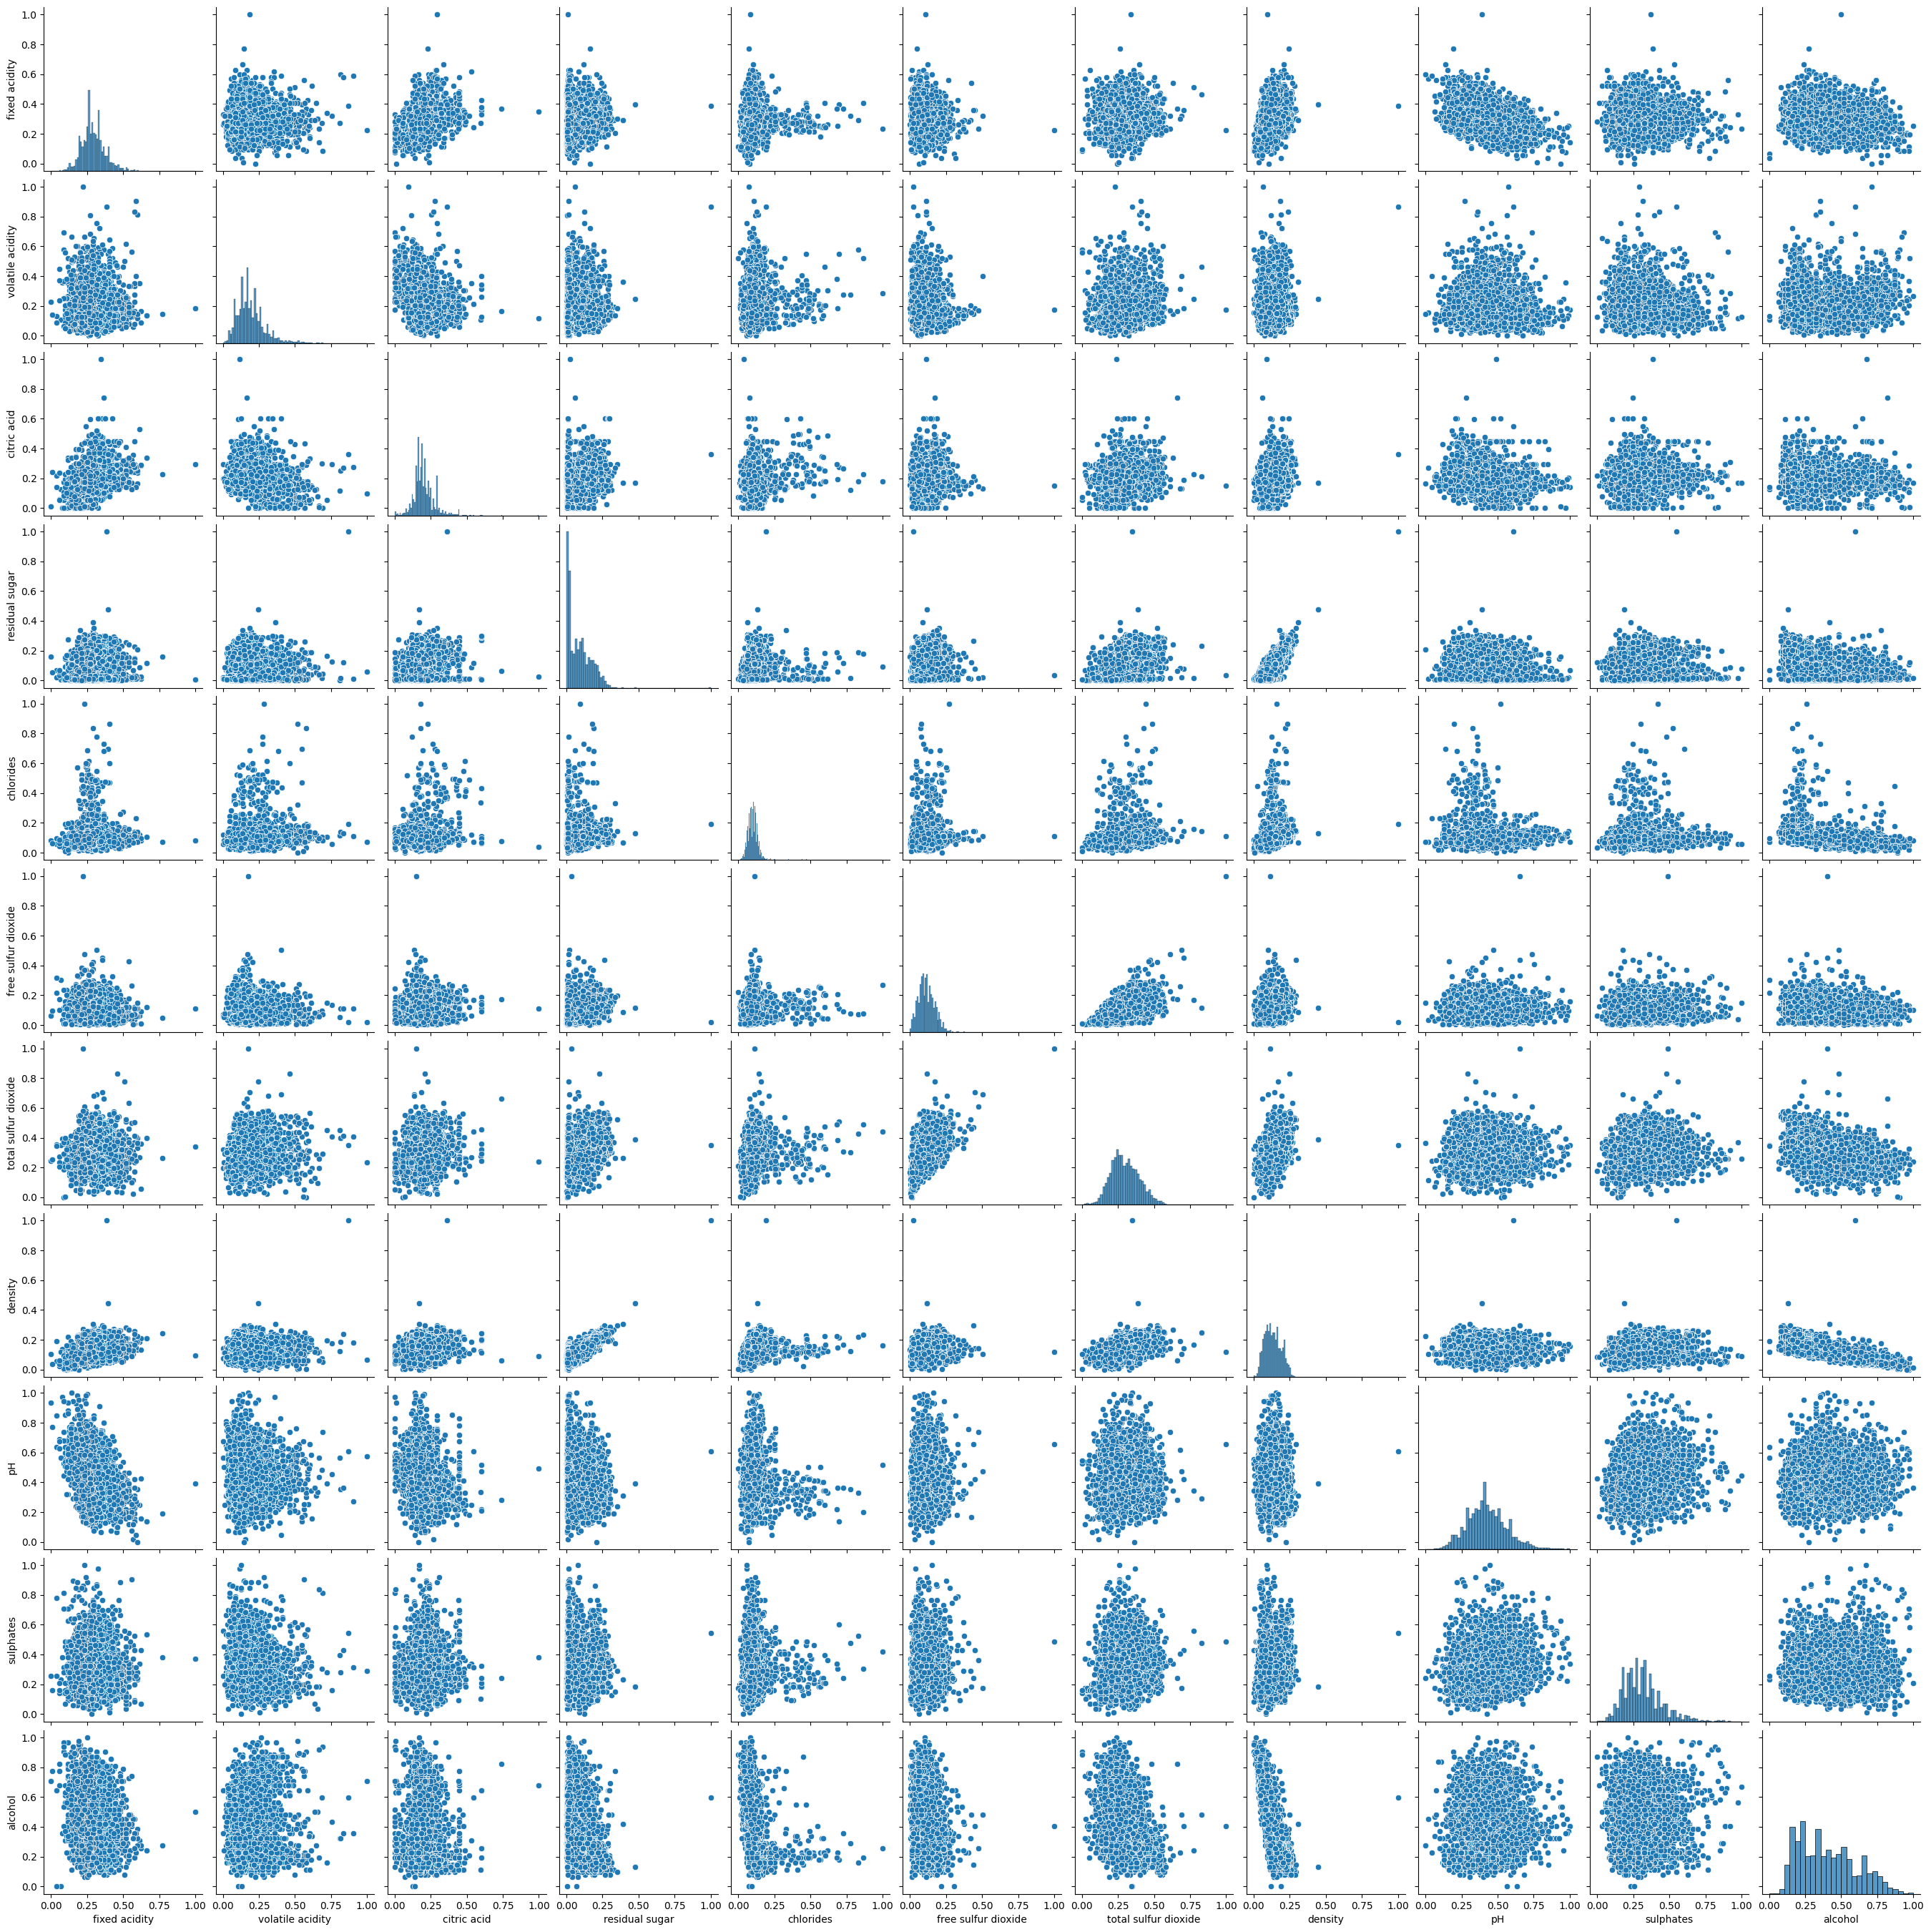

In [5]:
# read in csv
original_df = pd.read_csv('./winequality-white.csv')
wine_df = original_df.copy()

# one hot encode the quality column and add it back
one_hot_enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
quality_col = wine_df['quality'].to_numpy().reshape(-1,1)
quality_one_hot = one_hot_enc.fit_transform(quality_col)
wine_df['quality_vec'] = quality_one_hot.tolist()

# normalize each field of input with min-max normalization
for column_name, column_data in wine_df.items():
    if column_name == "quality" or column_name == "quality_vec":
        break
    else:
        raw_col_data = column_data.to_numpy()
        raw_min = np.min(raw_col_data)
        raw_max = np.max(raw_col_data)
        normalized_data = (raw_col_data - raw_min) / (raw_max - raw_min)
        # replace the column
        wine_df[column_name] = normalized_data.tolist()
# get rid of the original quality col
wine_df = wine_df.drop('quality', axis=1)

# output: 
print(wine_df.head(5))
input_df = wine_df.drop('quality_vec', axis=1)
sns.pairplot(wine_df)
plt.show()


## Exercise 2 : Building a Feed-Forward Neural Network(45 points in total)


### Training and Testing the Neural Network

Design a 5-layer artificial neural network, specifically a feed-forward multi-layer perceptron (using the sigmoid activation function), to classify the type of 'quality' given the other attributes in the data set, similar to the one mentioned in the paper above. Please note that this is a multi-class classification problem so select the right number of nodes accordingly for the output layer.

For training and testing the model, split the data into training and testing set by __90:10__ and use the training set for training the model and the test set to evaluate the model performance.

Consider the following hyperparameters while developing your model :

- Number of nodes in each hidden layer should be (23, 17, 13)
- Learning rate should be 0.4
- Number of epochs should be 500
- The sigmoid function should be used as the activation function in each layer
    - For your own learning, experiment with ReLU on hidden layers.
- Stochastic Gradient Descent should be used to minimize the error rate

__Output Requirements once the model has been trained :__

- A confusion matrix for all classes(should be 10 in this case), where you need to specify what is the true positive, true negative, false positive, and false negative cases for each category in the class
- The mean squared error (MSE) of the model on the test set after trained
- Training graph showing training and test mse at each epoch

__Notes :__

- Splitting of the dataset should be done __after__ the data preprocessing step.
- The mean squared error (MSE) values obtained __should be positive__.

In [6]:
#------------------------------#
#----- Model Architecture -----#
#------------------------------#

class MyModel(nn.Module):
    def __init__(self, input_size, h1_size, h2_size, h3_size, output_size):
        super(MyModel, self).__init__()
        self.layers = nn.Sequential(
            # input -> h1
            nn.Linear(input_size, h1_size),
            nn.Sigmoid(),
            # h1 -> h2
            nn.Linear(h1_size, h2_size),
            nn.Sigmoid(),
            # h2 -> h3
            nn.Linear(h2_size, h3_size),
            nn.Sigmoid(),
            # h3 -> output
            nn.Linear(h3_size, output_size)
        )
        
    def forward(self,x):
        return self.layers(x)

In [7]:
#------------------------------#
#---------- Data Prep ---------#
#------------------------------#
class MyDataset(Dataset):
    def __init__(self, df):
        # assumes the last column is the target one
        self.features = torch.tensor(df.iloc[:,:-1].values, dtype=torch.float32)
        self.labels = torch.tensor(np.array(df['quality_vec'].tolist()), dtype=torch.float32)

    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, index):
        return self.features[index], self.labels[index]
        


In [ ]:
#------------------------------#
#------- Model Training -------#
#------------------------------#

# split data 90:10
train_df, test_df = train_test_split(wine_df, test_size=0.1, random_state=42)

# hyperparams
lr = 0.4
num_epochs = 500
input_size = 11
h1_size = 23
h2_size = 17
h3_size = 13
output_size = 7

# NOTE: this notebook says there are 10 classes, there are really only 7. Although 
# the scale is from 1-10 only ratings 3-9 are actually used. 

# model initialization
model = MyModel(input_size=input_size, h1_size=h1_size, h2_size=h2_size,
                h3_size=h3_size, output_size=output_size)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=lr)

# dataloaders
train_dataset = MyDataset(train_df)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataset_eval = MyDataset(test_df)
test_loader_eval = DataLoader(test_dataset_eval, batch_size=32, shuffle=False)

train_mse_history = []
test_mse_history = []

for epoch in range(num_epochs):
    # training pass
    model.train()
    epoch_loss = 0.0
    for inputs, targets in train_loader:
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_mse_history.append(epoch_loss / len(train_loader))

    # test MSE
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader_eval:
            test_loss += criterion(model(inputs), targets).item()
    test_mse_history.append(test_loss / len(test_loader_eval))

print("Training complete.")
print(f"Final train MSE: {train_mse_history[-1]:.6f}")
print(f"Final test  MSE: {test_mse_history[-1]:.6f}")

Training complete.
Final train MSE: 0.087795
Final test  MSE: 0.090470


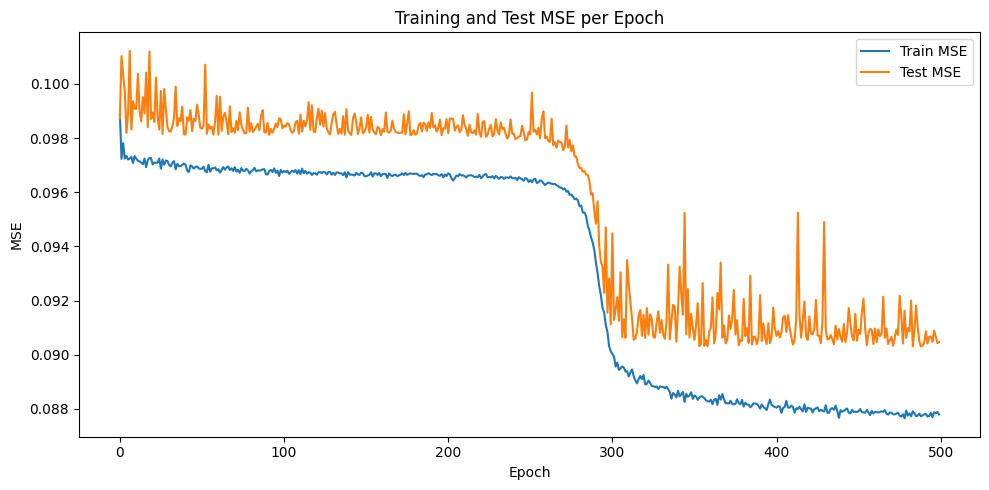

Test MSE after training: 0.090470


In [9]:
#------------------------------#
#------- MSE Plot & Score -----#
#------------------------------#

# training graph
plt.figure(figsize=(10, 5))
plt.plot(train_mse_history, label='Train MSE')
plt.plot(test_mse_history, label='Test MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Training and Test MSE per Epoch')
plt.legend()
plt.tight_layout()
plt.show()

# final test MSE
print(f"Test MSE after training: {test_mse_history[-1]:.6f}")

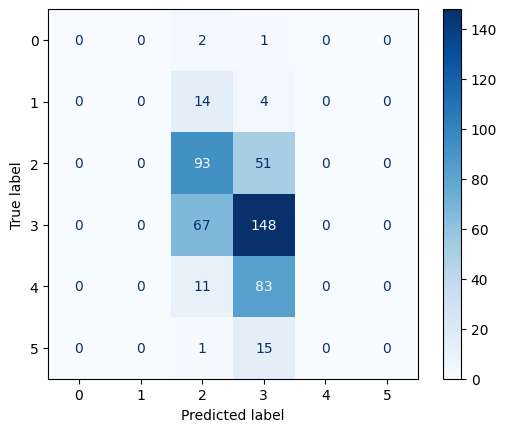

In [10]:
#------------------------------#
#-------- Model Testing -------#
#------------------------------#
model.eval()

test_dataset = MyDataset(test_df)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

all_preds = torch.tensor([])
all_targets = torch.tensor([])

with torch.no_grad():
    for inputs, labels in test_loader:
        preds = model(inputs)
        # get the class with the highest probability
        all_preds = torch.cat((all_preds, preds.argmax(dim=1)), dim=0)
        all_targets = torch.cat((all_targets, labels.argmax(dim=1)), dim=0)

cm = confusion_matrix(all_targets.numpy(), all_preds.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm.numpy() if torch.is_tensor(cm) else cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

## Exercise 3 : k-fold Cross Validation (15 points in total)

In order to avoid using biased models, use 10-fold cross validation to generalize the model based on the given data set.

__Requirements :__
- The MSE values during each iteration of the cross validation
- The overall average MSE value

__Note :__ The mean squared error (MSE) values obtained should be positive.

In [ ]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
fold_count = 0

all_train_MSE = []
all_test_MSE = [] 

for fold, (train_idx, val_idx) in enumerate(kf.split(wine_df)):
    fold_count += 1
    train_df = wine_df.iloc[train_idx]
    test_df = wine_df.iloc[val_idx]

    # build train and test model as before, copy paste code 

    # hyperparams
    lr = 0.4
    num_epochs = 500
    input_size = 11
    h1_size = 23
    h2_size = 17
    h3_size = 13
    output_size = 7

    # model initialization
    model = MyModel(input_size=input_size, h1_size=h1_size, h2_size=h2_size,
                    h3_size=h3_size, output_size=output_size)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # dataloaders
    train_dataset = MyDataset(train_df)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_dataset_eval = MyDataset(test_df)
    test_loader_eval = DataLoader(test_dataset_eval, batch_size=32, shuffle=False)

    train_mse_history = []
    test_mse_history = []

    for epoch in range(num_epochs):
        # training pass
        model.train()
        epoch_loss = 0.0
        for inputs, targets in train_loader:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_mse_history.append(epoch_loss / len(train_loader))

        # test MSE
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for inputs, targets in test_loader_eval:
                test_loss += criterion(model(inputs), targets).item()
        test_mse_history.append(test_loss / len(test_loader_eval))

    all_train_MSE.append(train_mse_history[-1])
    all_test_MSE.append(test_mse_history[-1])

avg_train_MSE = sum(all_train_MSE) / len(all_train_MSE)
avg_test_MSE = sum(all_test_MSE) / len(all_test_MSE)
print("Average train MSE: ", avg_train_MSE)
print("Average test MSE: ", avg_test_MSE)

Average train MSE:  0.08709510429289893
Average test MSE:  0.08687956277281046


## Exercise 4 : Hyperparameter Tuning (25 points)

Use either grid search or random search methodology to find the optimal number of nodes required in each hidden layer, as well as the optimal learning rate and the number of epochs, such that the MSE of the model is minimum for the given dataset.

__Requirements :__
- The set of optimal hyperparameters
- The mimimum MSE achieved using this set of optimal hyperparameters

__Note :__ Hyperparameter tuning takes a lot of time to execute. Make sure that you choose the appropriate number of each hyperparameter (at least 3 of each), and that you allocate enough time to execute your code.

In [12]:
random.seed(42)

# search space with random values
param_space = {
    'h1_size':    [16, 22, 27, 40],
    'h2_size':    [10, 17, 25, 35],
    'h3_size':    [8,  13, 18, 25],
    'lr':         [0.01, 0.1, 0.05, 0.5],
    'num_epochs': [100, 300, 500],
}

n_trials = 20  # number of random combinations to try

best_mse = float('inf')
best_params = None
results = []

for trial in range(n_trials):
    # sample one random combination
    params = {k: random.choice(v) for k, v in param_space.items()}

    # initialize empty mse list for each trial
    cv_mse = []
    kf = KFold(n_splits=3, shuffle=True, random_state=trial)

    # repeat same code again
    for train_idx, val_idx in kf.split(wine_df):
        train_fold = wine_df.iloc[train_idx]
        val_fold   = wine_df.iloc[val_idx]

        fold_model = MyModel(input_size=11,
                             h1_size=params['h1_size'],
                             h2_size=params['h2_size'],
                             h3_size=params['h3_size'],
                             output_size=7)
        fold_criterion = nn.MSELoss()
        fold_optimizer = optim.SGD(fold_model.parameters(), lr=params['lr'])

        fold_train_loader = DataLoader(MyDataset(train_fold), batch_size=32, shuffle=True)
        fold_val_loader   = DataLoader(MyDataset(val_fold),   batch_size=32, shuffle=False)

        for epoch in range(params['num_epochs']):
            fold_model.train()
            for inputs, targets in fold_train_loader:
                fold_optimizer.zero_grad()
                fold_criterion(fold_model(inputs), targets).backward()
                fold_optimizer.step()

        fold_model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in fold_val_loader:
                val_loss += fold_criterion(fold_model(inputs), targets).item()
        cv_mse.append(val_loss / len(fold_val_loader))

    mean_mse = sum(cv_mse) / len(cv_mse)
    results.append((mean_mse, params))
    print(f"Trial {trial+1:2d}: MSE={mean_mse:.6f}  params={params}")

    if mean_mse < best_mse:
        best_mse = mean_mse
        best_params = params

print("\n--- Best Result ---")
print(f"MSE:    {best_mse:.6f}")
print(f"Params: {best_params}")

Trial  1: MSE=0.098775  params={'h1_size': 16, 'h2_size': 10, 'h3_size': 18, 'lr': 0.1, 'num_epochs': 100}
Trial  2: MSE=0.101713  params={'h1_size': 22, 'h2_size': 10, 'h3_size': 8, 'lr': 0.5, 'num_epochs': 100}
Trial  3: MSE=0.097572  params={'h1_size': 16, 'h2_size': 10, 'h3_size': 13, 'lr': 0.1, 'num_epochs': 500}
Trial  4: MSE=0.099330  params={'h1_size': 16, 'h2_size': 17, 'h3_size': 25, 'lr': 0.1, 'num_epochs': 300}
Trial  5: MSE=0.097284  params={'h1_size': 27, 'h2_size': 10, 'h3_size': 13, 'lr': 0.5, 'num_epochs': 300}
Trial  6: MSE=0.096700  params={'h1_size': 27, 'h2_size': 17, 'h3_size': 13, 'lr': 0.05, 'num_epochs': 100}
Trial  7: MSE=0.096220  params={'h1_size': 16, 'h2_size': 35, 'h3_size': 8, 'lr': 0.05, 'num_epochs': 300}
Trial  8: MSE=0.096520  params={'h1_size': 27, 'h2_size': 10, 'h3_size': 25, 'lr': 0.01, 'num_epochs': 300}
Trial  9: MSE=0.096853  params={'h1_size': 16, 'h2_size': 25, 'h3_size': 18, 'lr': 0.1, 'num_epochs': 500}
Trial 10: MSE=0.096602  params={'h1_

## Optional Exercise - Neural Network and Gradient (0 points)
Suppose there is a neural network with a 2-3-2-1 structure. The nodes in the first hidden layer(from left to right) use a linear activation function while the second hidden layer neurons and the output neuron use a sigmoid activation function. The output ŷ is the prediction of the network.
h and ŷ are the values after applying the activation fuction.

Loss is calculated by $L = \frac{1}{2} (y - ŷ)^2$.

After a Feed-Forward Pass, write the updated weights during backward pass for $w_{ko}$, $w_{jk}$, and $w_{ij}$ with a learning rate of ${\lambda}$ (You just need to write 3 formula for those 3 stage of weight in general). You have to show how you compute ${\nabla}w$ for each weight mathematically.

Make sure that you show all your work. Refer to Lecture 8.

![ex2.png](ex2.png)

You may use the notations provided below.

$z_{j} = {\sum}w_{ij}x_{i} + b_{j}$; $x_{j} = z_{j}$

$z_{k} = {\sum}w_{jk}x_{j} + b_{x}$; $x_{k} = {\sigma}(z_{k})$

$z_{o} = {\sum}w_{ko}x_{k} + b_{o}$; $ŷ = {\sigma}(z_{o})$